In [ ]:
import io

file_path = "/content/WISDM_ar_v1.1_raw.txt"

# Read the raw file line by line
with open(file_path, 'r') as f:
    raw_lines = f.readlines()

cleaned_lines = []
for line in raw_lines:
    # Strip leading/trailing whitespace
    line = line.strip()

    # Skip empty lines
    if not line:
        continue

    # Remove semicolon from the end of the line if present (often in the 'z' column)
    if line.endswith(';'):
        line = line[:-1]

    # Split the line by commas, as the data is comma-separated
    parts = line.split(',')

    # Check if the line has the expected 6 fields: user, activity, timestamp, x, y, z
    if len(parts) == 6:
        cleaned_lines.append(','.join(parts)) # Join with comma for consistency

# Use StringIO to treat the list of cleaned lines as a file and read into a DataFrame
data = pd.read_csv(io.StringIO('\n'.join(cleaned_lines)), sep=',', header=None)

data.columns = ['user','activity','timestamp','x','y','z']

# Convert columns to appropriate types. 'z' column should no longer have semicolons.
data['x'] = data['x'].astype(float)
data['y'] = data['y'].astype(float)
data['z'] = data['z'].astype(float)

data.dropna(inplace=True)

In [ ]:
le = LabelEncoder()
data['label'] = le.fit_transform(data['activity'])

print("Activities:", le.classes_)


Activities: ['Downstairs' 'Jogging' 'Sitting' 'Standing' 'Upstairs' 'Walking']


In [ ]:
WINDOW_SIZE = 128
STEP_SIZE = 64

def create_windows(df):
    X = []
    y = []

    for i in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
        window = df[['x','y','z']].iloc[i:i+WINDOW_SIZE].values
        label = df['label'].iloc[i:i+WINDOW_SIZE].mode()[0]
        X.append(window)
        y.append(label)

    return np.array(X), np.array(y)

X, y = create_windows(data)

print("Windowed Data Shape:", X.shape)


Windowed Data Shape: (16975, 128, 3)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (13580, 128, 3) Test: (3395, 128, 3)


In [ ]:
model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(128,3)),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(256, 3, activation='relu'),
    MaxPooling1D(2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 28, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3584)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       458,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 584,326 (2.23 MB)

 Trainable params: 583,942 (2.23 MB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64
)


Epoch 1/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - accuracy: 0.7288 - loss: 0.8519 - val_accuracy: 0.9102 - val_loss: 0.2723
Epoch 2/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.9102 - loss: 0.2593 - val_accuracy: 0.9490 - val_loss: 0.1507
Epoch 3/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - accuracy: 0.9492 - loss: 0.1575 - val_accuracy: 0.9691 - val_loss: 0.0874
Epoch 4/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - accuracy: 0.9591 - loss: 0.1271 - val_accuracy: 0.9761 - val_loss: 0.0710
Epoch 5/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.9743 - loss: 0.0780 - val_accuracy: 0.9735 - val_loss: 0.0793
Epoch 6/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.9812 - loss: 0.0620 - val_accuracy: 0.9788 - val_loss: 0.0707
Epoch 7/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - accuracy: 0.9855 - loss: 0.0469 - val_accuracy: 0.9823 - val_loss: 0.0507
Epoch 8/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.9897 - loss: 0.0391 - 

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9812 - loss: 0.0963
Test Accuracy: 0.9817378520965576


107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


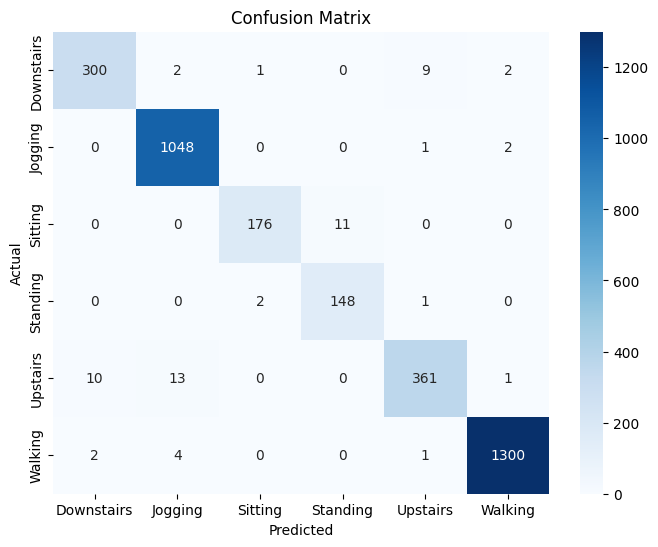

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
